#1.Problem Statement

This dataset simulates aircraft engine health over time using sensor measurements. As engines age, sensor patterns change, allowing us to predict how long an engine can operate before failure.

**What the 21 Sensors Reflect?**

- The sensors are strategically placed to monitor performance across various engine stages:

1. **Temperature (7 sensors)**: Measures heat at the inlet, fan outlet, and various compressor and turbine stages (e.g., LPC outlet, HPC outlet, HPT outlet, and LPT outlet). These reflect thermal efficiency and potential overheating due to component wear.
2. **Pressure (9 sensors)**: Tracks pressure levels at the fan, compressors, and burner. Fluctuations often indicate airflow issues, leaks, or decreasing compression efficiency.
3. **Speed (2 sensors)**: Monitors the Physical Fan Speed (
) and Physical Core Speed (
). Variations in these speeds relative to fuel flow can signal mechanical friction or degradation.
4. **Flow and Gas Ratios (3 sensors)**: Measures Fuel Flow (
), bleeding air, and air-to-fuel ratios. These reflect how hard the engine must work to maintain thrust as it ages

#2.Libraries and Data Loading

In [91]:
!pip install catboost
!pip install lightgbm
!pip install xgboost

In [92]:
# import all required libraries and tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import warnings
import warnings
warnings.filterwarnings('ignore')

#importing metrics
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

#importing ML Algorithums
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import time
import joblib

In [ ]:
# to see all the features
pd.set_option('display.max_columns', None)

#loading the dataset
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML Project/Aerospace Project/train_FD001.txt", sep=" ", header=None)
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML Project/Aerospace Project/test_FD001.txt", sep=" ", header=None)
rul = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML Project/Aerospace Project/RUL_FD001.txt", header=None)

# print out the shapes of all 3 dataframes
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL shape:", rul.shape)

Train shape: (20631, 28)
Test shape: (13096, 28)
RUL shape: (100, 1)


In [94]:
train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [95]:
test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN


#3.Data Preprocessing and cleaning

##3.1.Dealing with missing data

- There are 2 features that carry no importance as they don't have any value written inside them. So we will drop those two features.

In [96]:
train.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [97]:
test.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [98]:
train = train.dropna(axis=1)
test = test.dropna(axis=1)

##3.2.Naming the features

In [99]:
cols = ['unit', 'cycle',
        'op_setting1', 'op_setting2', 'op_setting3'] + \
       [f'sensor{i}' for i in range(1, 22)]

train.columns = cols
test.columns = cols

In [100]:
train.head()

,unit,cycle,op_setting1,op_setting2,op_setting3,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9,sensor10,sensor11,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


##3.3.Calcutate the RUL (target feature)

In [101]:
# find max cycle per engine
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# merge back
train = train.merge(max_cycle, on='unit')

# calculate RUL
train['RUL'] = train['max_cycle'] - train['cycle']

In [102]:
train.head()

,unit,cycle,op_setting1,op_setting2,op_setting3,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9,sensor10,sensor11,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


##3.4.Removing un-necessary features

In this subset (FD001), several sensors (specifically S1, S5, S6, S10, S16, S18, and S19) provide constant values with zero variance. Because they do not change as the engine wears down, so we are going to discard them during preprocessing to focus on the 14 sensors that actually trend with engine degradation.

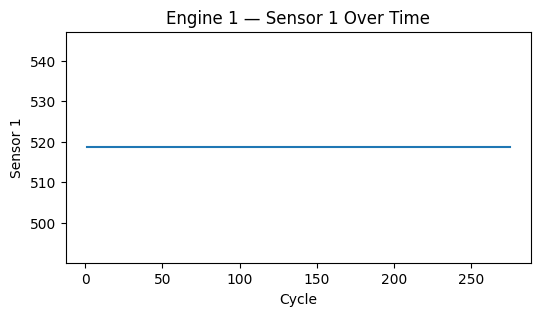

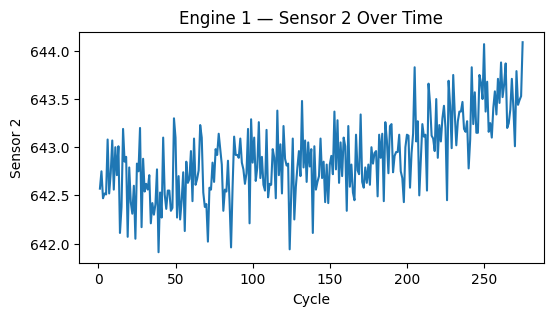

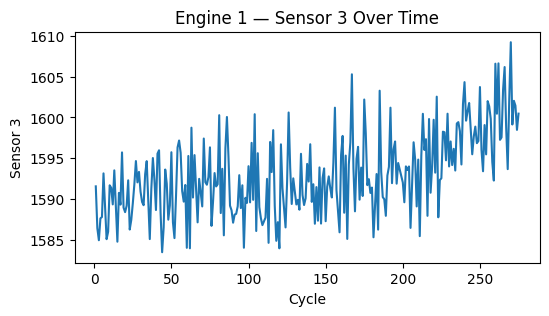

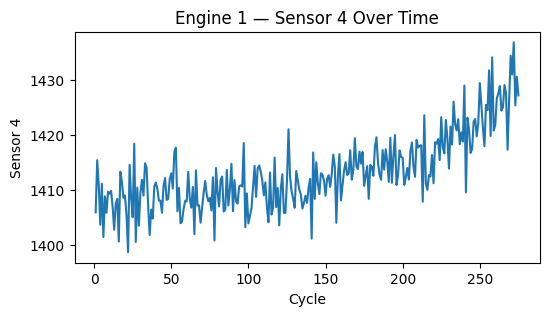

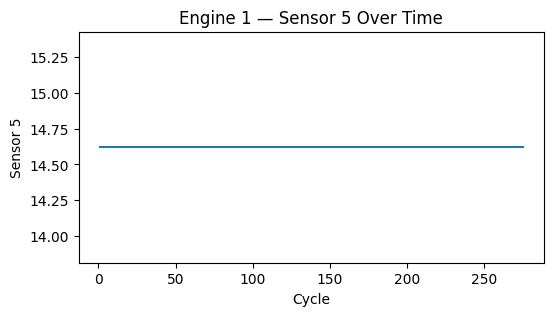

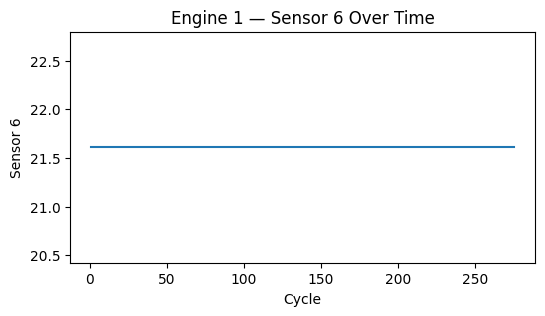

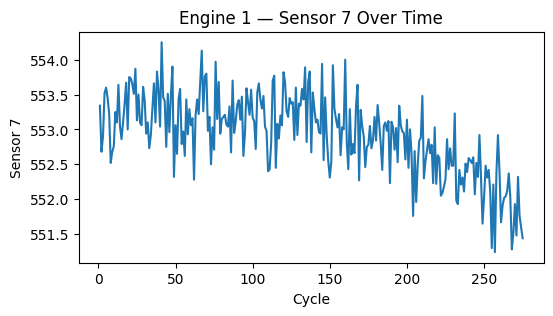

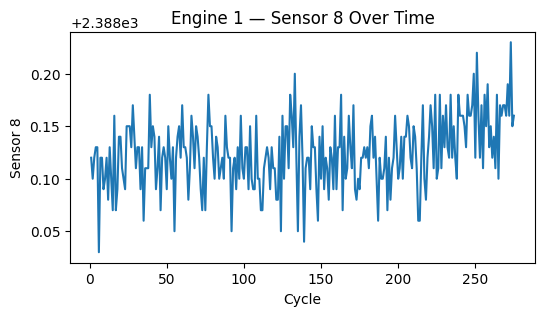

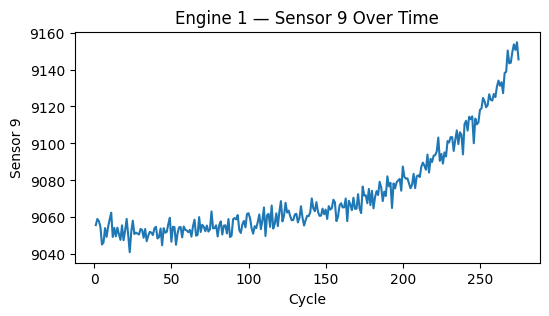

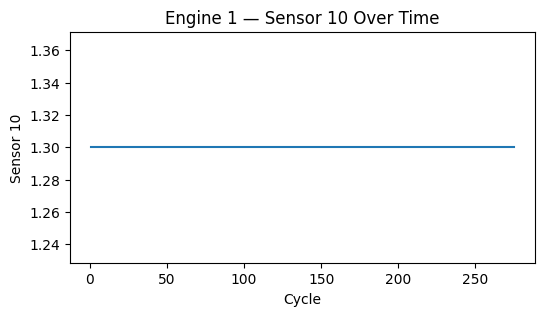

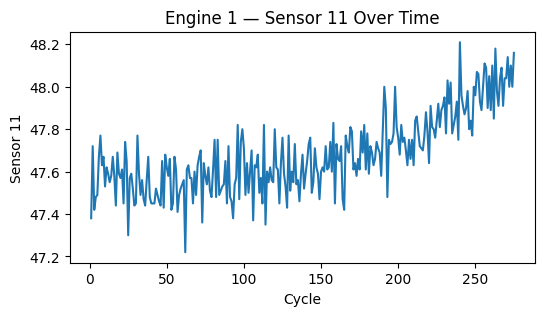

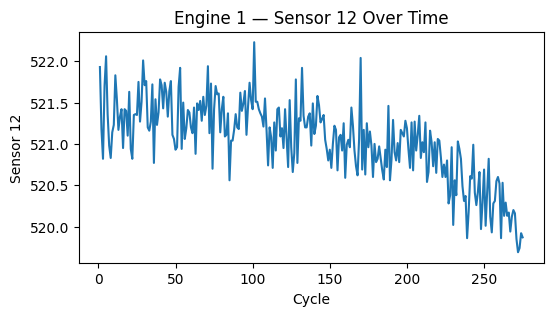

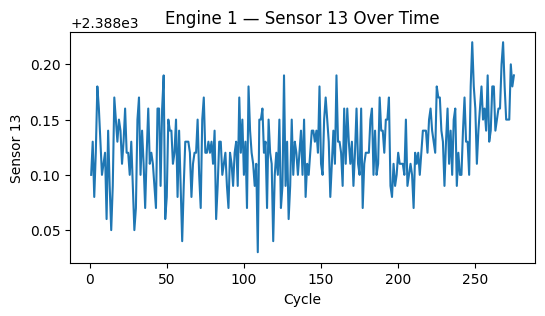

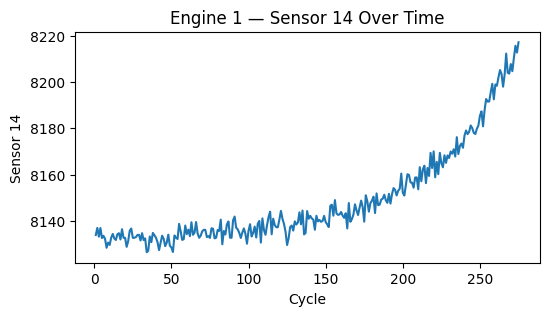

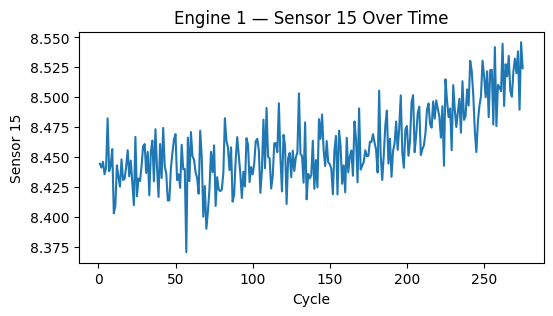

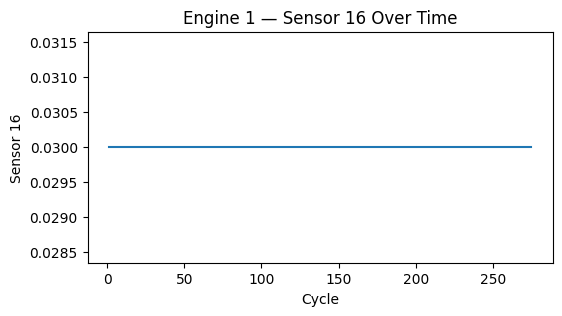

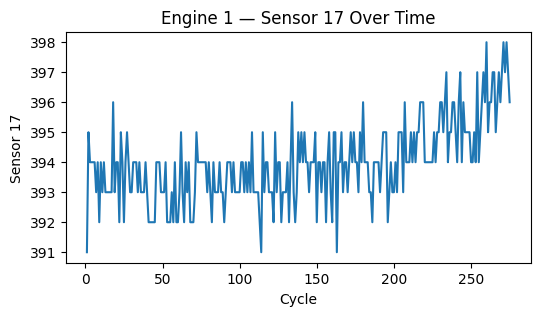

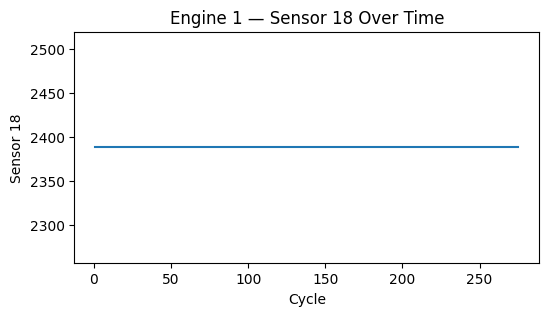

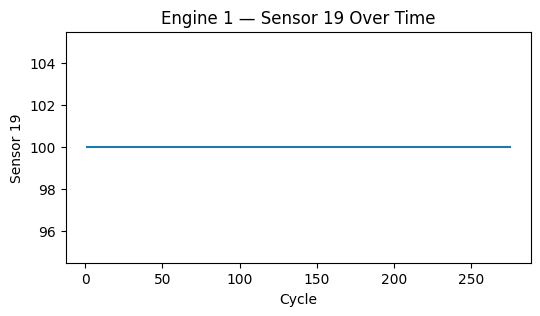

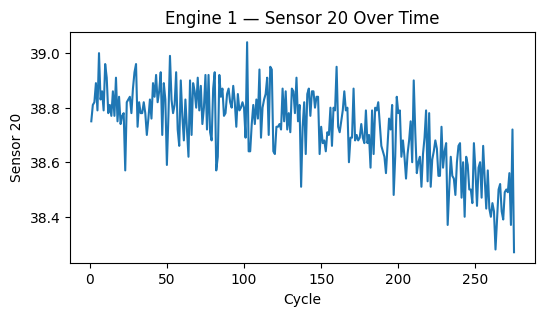

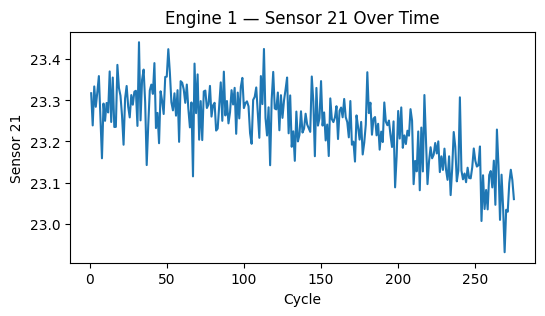

In [103]:
import matplotlib.pyplot as plt
engine_1 = train[train['unit'] == 56]
for i in range(1, 22):
    plt.figure(figsize=(6,3))
    plt.plot(engine_1['cycle'], engine_1[f'sensor{i}'])
    plt.title(f'Engine 1 — Sensor {i} Over Time')
    plt.xlabel('Cycle')
    plt.ylabel(f'Sensor {i}')
    plt.show()

In [104]:
flat_sensors = []

for col in train.columns:
    if "sensor" in col and train[col].nunique() == 1:
        flat_sensors.append(col)

print("Flat sensors:", flat_sensors)

Flat sensors: ['sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


- These sensors showed constant values across engine cycles and were removed, as they do not contribute to degradation prediction.

In [105]:
train = train.drop(columns=flat_sensors)
test = test.drop(columns=flat_sensors)

##3.5.Adding rolling mean and std

Adding rolling features and differences is a critical step because raw sensor data in C-MAPSS is often noisy and fluctuates significantly cycle-to-cycle. By calculating the rolling mean, you smooth out short-term noise to reveal the underlying degradation trend, while the rolling standard deviation captures increasing instability or vibration as the engine nears failure. Additionally, the difference (diff) feature provides the model with the "velocity" of change, helping it distinguish between stable operation and the rapid performance drops characteristic of an engine’s end-of-life.


In [106]:
important_sensors = [
    'sensor2','sensor3','sensor4','sensor7','sensor8',
    'sensor9','sensor11','sensor12','sensor13','sensor14',
    'sensor15','sensor17','sensor20','sensor21'
]

def add_features(df):
    df = df.copy()

    for s in important_sensors:
        df[f'{s}_mean5'] = df.groupby(train['unit'])[s].rolling(5).mean().reset_index(level=0, drop=True)
        df[f'{s}_std5'] = df.groupby(train['unit'])[s].rolling(5).std().reset_index(level=0, drop=True)
        df[f'{s}_diff'] = df.groupby(train['unit'])[s].diff()

    df.fillna(method="bfill", inplace=True)
    return df

In [107]:
train = add_features(train)
X_test = add_features(test)

##3.6.keeping last record of each engine

In [108]:
# keep last record of each engine
test_last = X_test.groupby("unit").last().reset_index()

# remove unit column
X_test = test_last.drop(columns=["unit","cycle"])

##3.8.Creating true varaiables

In [109]:
rul.columns = ["RUL"]
y_true = rul["RUL"].values

##3.9.Pruning the records to focus entirely on degraded engine records

By filtering the dataset for RUL values below 150, you are performing hard pruning to focus the model exclusively on the active degradation phase of the engine's lifecycle. While clipping (using .clip) retains early-cycle data but caps the target value, this filtering step physically removes the "healthy" or "steady-state" records entirely. This forces the model to train only on sequences where sensor signatures show visible wear-and-tear, effectively eliminating the "flat-line" data that can dilute the gradient during training and lead to biased predictions in the critical final flight cycles.


In [ ]:
train = train[train["RUL"] < 150]

##3.9.Clipping

The primary reason for train.clip(upper=125) is that jet engines typically operate in a "healthy" state with negligible degradation for a significant portion of their early life. During this period, sensor readings remain stable and do not show a clear downward trend, making it nearly impossible for a model to distinguish between an engine with 300 cycles left and one with 200 cycles left. By clipping the RUL, you tell the model to treat all "healthy" cycles as having the same maximum life value, focusing its learning power on the linear degradation phase where sensor changes actually correlate with the engine's approaching failure.


In [110]:
train = train.clip(upper=125)

#4.Machine Learning Model Building

##4.1.Split data to input and output feature

In [111]:
# drop non-features
X = train.drop(columns=["unit", "cycle", "max_cycle", "RUL"])
y = train["RUL"]

##4.2.Building ML pipeline to train and evaluate performance of different ML models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Bagging": BaggingRegressor(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(objective='reg:squarederror', verbosity=0),
    "LightGBM": LGBMRegressor(verbose=-1),
    "CatBoost": CatBoostRegressor(verbose=0)
}

In [ ]:
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

In [ ]:
# to calculate time for this cell
start = time.time()
results = []

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

    mae = -scores['test_MAE'].mean()
    rmse = -scores['test_RMSE'].mean()
    r2 = scores['test_R2'].mean()

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values(by="MAE")

results_df

end = time.time()
print("Time taken:", end-start)

##4.3.Graphical view of metrics

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xticks(rotation=75)
plt.title("Model Comparison (MAE)")
plt.ylabel("MAE (Lower is Better)")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=75)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=75)
plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

##4.4.Selecting best model and evaluate it on testing dataset

In [ ]:
# final model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# train on full training data
rf.fit(X, y)

In [ ]:
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label="True RUL")
plt.plot(y_pred, label="Predicted RUL")
plt.legend()
plt.title("True vs Predicted Remaining Useful Life")
plt.xlabel("Engine")
plt.ylabel("RUL")
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction Accuracy")
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')
plt.show()

In [ ]:
# Save the trained Random Forest model
joblib.dump(rf, "rul_xg_model.pkl", compress=3)